In [1]:
import numpy as np
import itertools
import matplotlib.pyplot as plt
%config InlineBackend.figure_format = 'retina'

In [2]:
from tensornetworkrg.tnrg import TensorNetworkRG2D

# (3 Dec 2025) Stability of the ordered-phase (SSB) fixed point for the negative-$z$ transition (repulsive-core singularity, or Lee-Yang edge singularity)

SSB of the $\mathcal{PT}$ symmetry happens when the activity $z$ decreases from 0 to the repulsive-core singularity $z_c^-$, whose best estimate is
$$
z_c^- = −0.119338886
$$

In [3]:
zd = -0.119338886

The $\mathcal{PT}$ can be easily impose in TNRG by using only real-valued tensors.
Therefore, we will compare the tensor RG flows genereated by the TRG in the following two situations:
1. The initial tensor is real-valued
2. The initial tensor is complex-valued

In the case 1, since the $\mathcal{PT}$ symmetry is exactly preseved, the SSB fixed point should be stable to all numerical perturbations, as long as the tensor is real.
In the case 2, we expect that errors due to numerical precision will break the $\mathcal{PT}$ symmetry and the SSB fixed point will become unstable.
Let's check.

We will use the same degeneracy index $X$ as the positive-$z$ transition (see Sec.I of [this notebook](Sym-SSB-zplus.ipynb)) to visualize the tensor RG flow.

## I. RG flows generated by the TRG starting with a complex-tensor representation of the model

The initial tensor can be chosen to be complex by taking the square root of the bond matrix $\sigma$ and apply it on the 4 legs of the main tensor.

In [4]:
# The critical value is zd = -0.1193
hdsq1NN = TensorNetworkRG2D("hardsquare1NN")
hdsq1NN.model_parameters = {"activity": zd}
hdsq1NN.generate_initial_tensor(scheme="trg") # complex representation
A0 = hdsq1NN.get_tensor()
print("Data type of the initial tensor: {}".format(A0.dtype))

Data type of the initial tensor: complex128


In [5]:
initenRep = "trg"
scheme = "trg"
ver = "general"
chi = 10
dtol = 1e-10
rgpars = {"chi": chi, "dtol": dtol, "display": False}
rg_n = 31
Xdata = []
zTry = [-0.15, -0.126, zd, -0.116, -0.105]
for z in zTry:
    hdsq1NN = TensorNetworkRG2D("hardsquare1NN")
    hdsq1NN.model_parameters = {"activity": z}
    hdsq1NN.generate_initial_tensor(scheme=initenRep)
    Xflow = []
    for k in range(rg_n):
        lrerr, SPerrs = hdsq1NN.rgmap(rgpars, scheme=scheme, ver=ver)
        curX = hdsq1NN.degIndX2()
        Xflow.append(curX)
    Xdata.append(Xflow)

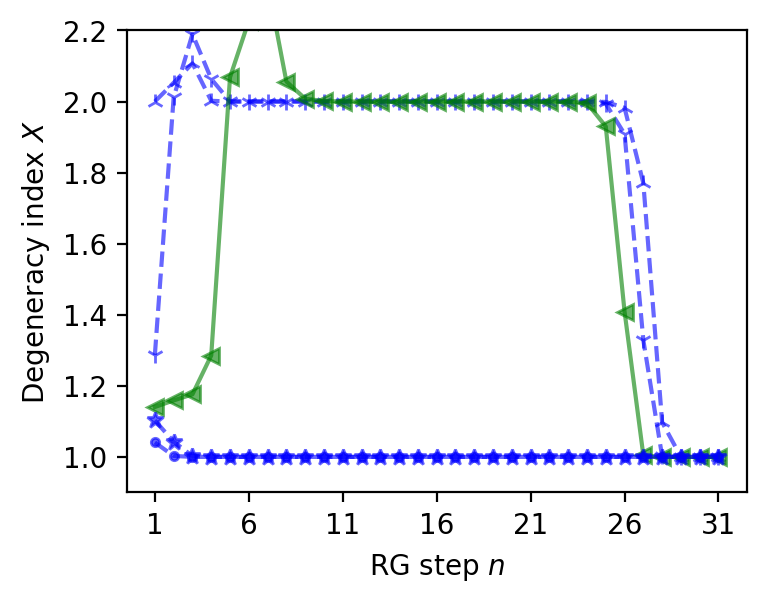

In [6]:
marker = itertools.cycle(('2', '1', '<', '*', '.', '3', '4'))
plt.figure(figsize=(4,3))
rgnList = np.arange(rg_n) + 1
rgTicks = np.arange(rg_n, step=5) + 1
for z, Xflow in zip(zTry, Xdata):
    curmarker = next(marker)
    if z == zd:
        plt.plot(rgnList, Xflow, "g" + curmarker + "-", alpha=0.6,
                label=r"$z$={:.3f}".format(z))
    else:
        plt.plot(rgnList, Xflow, "b" + curmarker + "--", alpha=0.6,
                label=r"$z$={:.3f}".format(z))
    plt.ylabel("Degeneracy index $X$")
    plt.xlabel("RG step $n$")

#plt.hlines(1, 0, rg_n-1, color="k", linestyles='dashed')
#plt.hlines(2, 0, rg_n-1, color="k", linestyles='dashed')
plt.ylim(0.9, 2.2)
#plt.title("Complex-valued initial tensor")
#plt.legend()
plt.xticks(rgTicks)
plt.savefig("model-znegCflow.pdf",  bbox_inches='tight', dpi=200)
plt.show()

We see that for $z < z_c^-$, the tensor first flows to the SSB fixed point, and then flows away after $n=26$ RG steps.

## II. RG flows generated by the TRG starting with a real-tensor representation of the model

We can apply the bond matrix $\sigma$ to two legs of the main tensor that point towards the postive $x,y$ directions.

In [7]:
# The critical value is zd = -0.1193
hdsq1NN = TensorNetworkRG2D("hardsquare1NN")
hdsq1NN.model_parameters = {"activity": zd}
hdsq1NN.generate_initial_tensor(scheme="trgR") # real representation
A0 = hdsq1NN.get_tensor()
print("Data type of the initial tensor: {}".format(A0.dtype))

Data type of the initial tensor: float64


In [8]:
initenRep = "trgR"
scheme = "trg"
ver = "general"
chi = 10
dtol = 1e-10
rgpars = {"chi": chi, "dtol": dtol, "display": False}
rg_n = 51
XdataR = []
zTry = [-0.15, -0.126, zd, -0.116, -0.105]
for z in zTry:
    hdsq1NN = TensorNetworkRG2D("hardsquare1NN")
    hdsq1NN.model_parameters = {"activity": z}
    hdsq1NN.generate_initial_tensor(scheme=initenRep)
    Xflow = []
    for k in range(rg_n):
        lrerr, SPerrs = hdsq1NN.rgmap(rgpars, scheme=scheme, ver=ver)
        curX = hdsq1NN.degIndX2()
        Xflow.append(curX)
    XdataR.append(Xflow)

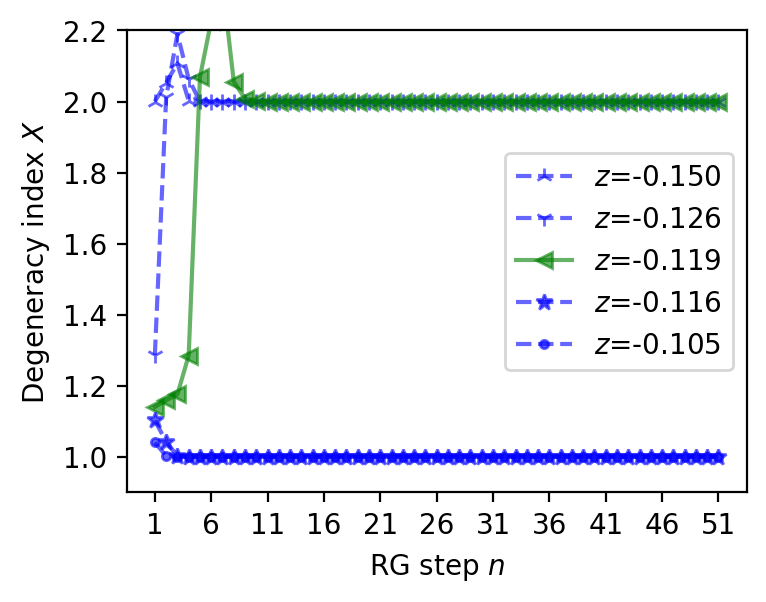

In [9]:
marker = itertools.cycle(('2', '1', '<', '*', '.', '3', '4'))
plt.figure(figsize=(4,3))
rgnList = np.arange(rg_n) + 1
rgTicks = np.arange(rg_n, step=5) + 1
for z, Xflow in zip(zTry, XdataR):
    curmarker = next(marker)
    if z == zd:
        plt.plot(rgnList, Xflow, "g" + curmarker + "-", alpha=0.6,
                label=r"$z$={:.3f}".format(z))
    else:
        plt.plot(rgnList, Xflow, "b" + curmarker + "--", alpha=0.6,
                label=r"$z$={:.3f}".format(z))
    plt.ylabel("Degeneracy index $X$")
    plt.xlabel("RG step $n$")

#plt.hlines(1, 0, rg_n-1, color="k", linestyles='dashed')
#plt.hlines(2, 0, rg_n-1, color="k", linestyles='dashed')
plt.ylim(0.9, 2.2)
# plt.title("Real-valued initial tensor")
plt.legend()
plt.xticks(rgTicks)
plt.savefig("model-znegRflow.pdf",  bbox_inches='tight', dpi=200)
plt.show()

The figure shows that the SSB fixed point is stable upto $n=51$ RG steps.
We have checked numerically the stability persists even after $n=100$ RG steps.
This is consistent with our expectation that the SSB fixed point should be strictly stable since the $\mathcal{PT}$ is excatly preseved.